# Deep Learning Approaches for Bone Fracture Classification

### Imports

In [2]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
import matplotlib.pyplot as plt
import numpy as np
import json
from tensorflow.keras.models import load_model
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.applications import ResNet50

## **Dataset 2**

**Source** 

https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data?resource=download&fbclid=IwY2xjawI1KhtleHRuA2FlbQIxMAABHaFf5nsVIsXCSnM21MOxYKxxvNIEr_Fcg09zvrxeVPThXgJBZ6tZO1sCGg_aem_3dnxMVu9PRMt4DOrnp6t3A

### From Scratch

In [3]:
# Define the base directory for your dataset.
base_dir = r"C:\Users\Nassi\Desktop\education\ESPRIT\4eme\S2\DL\Lab 1\archive (4)\Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification"

# Create training, validation, and test datasets.
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

img_size = (224, 224)
batch_size = 32

# Load the original dataset
orig_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    batch_size=batch_size,
    image_size=img_size,
    shuffle=True
)

# Save class_names before ignoring errors
class_names = orig_train_ds.class_names
print("Classes:", class_names)

orig_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="binary",
    batch_size=batch_size,
    image_size=img_size,
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    batch_size=batch_size,
    image_size=img_size,
    shuffle=False
)

train_ds = orig_train_ds.apply(tf.data.experimental.ignore_errors())
val_ds = orig_val_ds.apply(tf.data.experimental.ignore_errors())

Found 9246 files belonging to 2 classes.
Classes: ['fractured', 'not fractured']
Found 829 files belonging to 2 classes.
Found 506 files belonging to 2 classes.
Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [4]:
print("Train dataset cardinality:", train_ds.cardinality().numpy())
print("Val dataset cardinality:", val_ds.cardinality().numpy())

Train dataset cardinality: -2
Val dataset cardinality: -2


In [5]:
for images, labels in train_ds.take(1):
    print(images.shape)

(32, 224, 224, 3)


C:\Users\Nassi\AppData\Local\Temp\ipykernel_28104\2645181938.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {class_names[int(labels[i].numpy())]}")


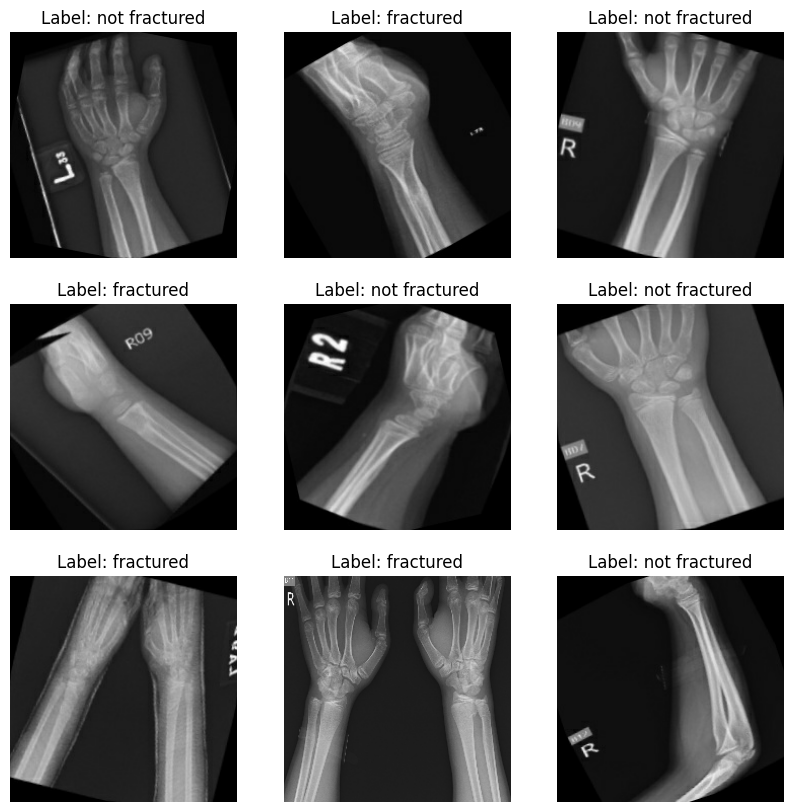

In [6]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Label: {class_names[int(labels[i].numpy())]}")
        plt.axis("off")
plt.show()

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

# Rescaling layer to [0,1]
preprocess_input = tf.keras.layers.Rescaling(1./255)

In [8]:
input_shape = img_size + (3,)  # (224,224,3)

model = models.Sequential([
    layers.Input(shape=input_shape),
    data_augmentation,
    preprocess_input,
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,457 (49.36 MB)

 Trainable params: 12,939,009 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [49]:
# Make the training dataset repeat indefinitely.
train_ds = train_ds.repeat()

# Calculate how many steps per epoch
steps_per_epoch = 9246 // 32  

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    callbacks=[early_stop]
)

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.7554 - loss: 0.5029 - val_accuracy: 0.8430 - val_loss: 0.4363
Epoch 2/10


C:\Users\Nassi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


288/288 ━━━━━━━━━━━━━━━━━━━━ 631s 2s/step - accuracy: 0.7755 - loss: 0.4791 - val_accuracy: 0.6607 - val_loss: 0.8897
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 339s 1s/step - accuracy: 0.7890 - loss: 0.4503 - val_accuracy: 0.8562 - val_loss: 0.3913
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 183s 637ms/step - accuracy: 0.7997 - loss: 0.4356 - val_accuracy: 0.8326 - val_loss: 0.4314
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 185s 643ms/step - accuracy: 0.8117 - loss: 0.4194 - val_accuracy: 0.6122 - val_loss: 2.6443
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 182s 631ms/step - accuracy: 0.8023 - loss: 0.4364 - val_accuracy: 0.8640 - val_loss: 0.3946


In [50]:
test_ds_clean = test_ds.apply(tf.data.experimental.ignore_errors())


test_loss, test_acc = model.evaluate(test_ds_clean)
print("Test Accuracy:", test_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.6800 - loss: 0.4872
Test Accuracy: 0.8458333611488342


In [51]:
# Save the model in the keras format:
model.save(r"C:\Users\Nassi\Desktop\education\ESPRIT\4eme\S2\DL\Lab 1\saved_model_V2.keras")

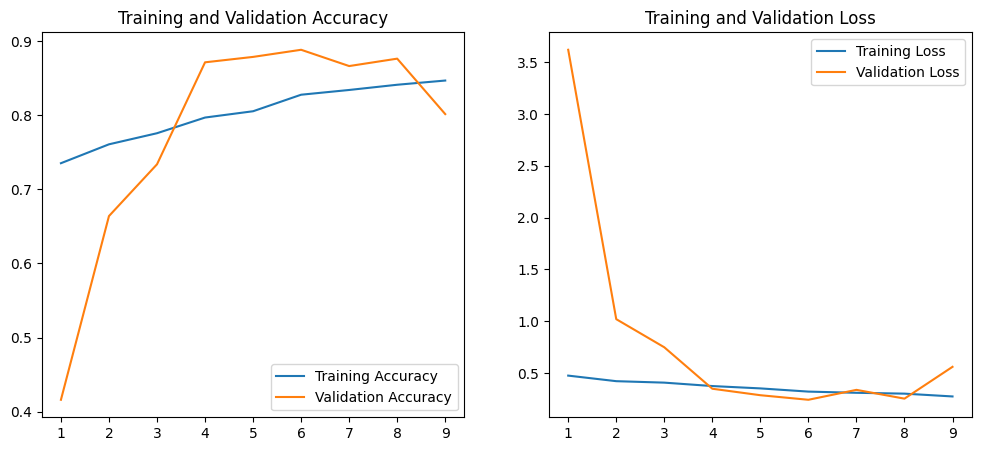

In [ ]:
# Assuming `history` is the output from model.fit()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


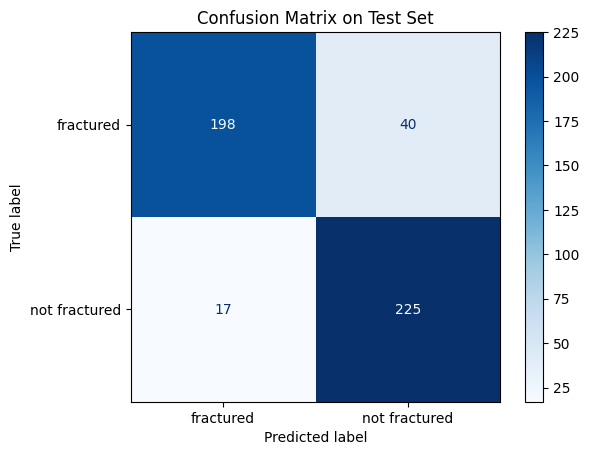

In [ ]:
# Get predictions and true labels from the test dataset.
y_true = []
y_pred = []

test_ds_clean = test_ds.apply(tf.data.experimental.ignore_errors())

for images, labels in test_ds_clean:
    preds = model.predict(images)
    # Convert predictions to binary
    preds_binary = (preds.flatten() > 0.5).astype(int)
    y_pred.extend(preds_binary.tolist())
    y_true.extend(labels.numpy().flatten().astype(int).tolist())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.show()

### Pretrained models

#### Feature Extraction model

In [ ]:
# Define image size and input shape.
img_size = (224, 224)
input_shape = img_size + (3,)

# Load pretrained ResNet50 without the top classification layers.
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)

# Freeze the base model
base_model.trainable = False

# Build the new model on top
inputs = tf.keras.Input(shape=input_shape)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
feature_extractor_model = tf.keras.Model(inputs, outputs)

# Compile and train
feature_extractor_model.compile(optimizer="adam",
                                loss="binary_crossentropy",
                                metrics=["accuracy"])

history_feat = feature_extractor_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    callbacks=[early_stop]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 259s 3us/step
Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5187 - loss: 0.7392

C:\Users\Nassi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


288/288 ━━━━━━━━━━━━━━━━━━━━ 439s 2s/step - accuracy: 0.5188 - loss: 0.7391 - val_accuracy: 0.6232 - val_loss: 0.6554
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 779s 3s/step - accuracy: 0.5596 - loss: 0.6823 - val_accuracy: 0.6690 - val_loss: 0.6458
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 769s 3s/step - accuracy: 0.5786 - loss: 0.6652 - val_accuracy: 0.5685 - val_loss: 0.6638
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 762s 3s/step - accuracy: 0.5963 - loss: 0.6541 - val_accuracy: 0.5516 - val_loss: 0.6655
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 408s 1s/step - accuracy: 0.6028 - loss: 0.6492 - val_accuracy: 0.6295 - val_loss: 0.6475


In [19]:
# After training your feature extraction model:
feature_extractor_model.save(r"C:\Users\Nassi\Desktop\education\ESPRIT\4eme\S2\DL\Lab 1\feature_extraction_model.keras")

#### Fine Tuning Model

In [ ]:
# Unfreeze some layers in the base model
base_model.trainable = True

# Use a lower learning rate for fine-tuning
fine_tune_lr = 1e-5
feature_extractor_model.compile(optimizer=tf.keras.optimizers.Adam(fine_tune_lr),
                                loss="binary_crossentropy",
                                metrics=["accuracy"])

history_ft = feature_extractor_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    callbacks=[early_stop]
)

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 723s 2s/step - accuracy: 0.5073 - loss: 8.6245 - val_accuracy: 0.4155 - val_loss: 26.0611
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 690s 2s/step - accuracy: 0.9037 - loss: 0.2861 - val_accuracy: 0.3922 - val_loss: 4.3094
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 682s 2s/step - accuracy: 0.9737 - loss: 0.1093 - val_accuracy: 0.4725 - val_loss: 1.1473
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 682s 2s/step - accuracy: 0.9867 - loss: 0.0563 - val_accuracy: 0.9043 - val_loss: 0.2687
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 689s 2s/step - accuracy: 0.9929 - loss: 0.0281 - val_accuracy: 0.9223 - val_loss: 0.2205
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 705s 2s/step - accuracy: 0.9944 - loss: 0.0209 - val_accuracy: 0.9537 - val_loss: 0.1161
Epoch 7/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 711s 2s/step - accuracy: 0.9956 - loss: 0.0156 - val_accuracy: 0.9746 - val_loss: 0.0705
Epoch 8/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 711s 2s/step - accuracy: 0.9963 - loss: 0.0148 - val_acc

In [21]:
feature_extractor_model.save(r"C:\Users\Nassi\Desktop\education\ESPRIT\4eme\S2\DL\Lab 1\finetuned_model.keras")

### Comparison

#### Validation accuracy and loss

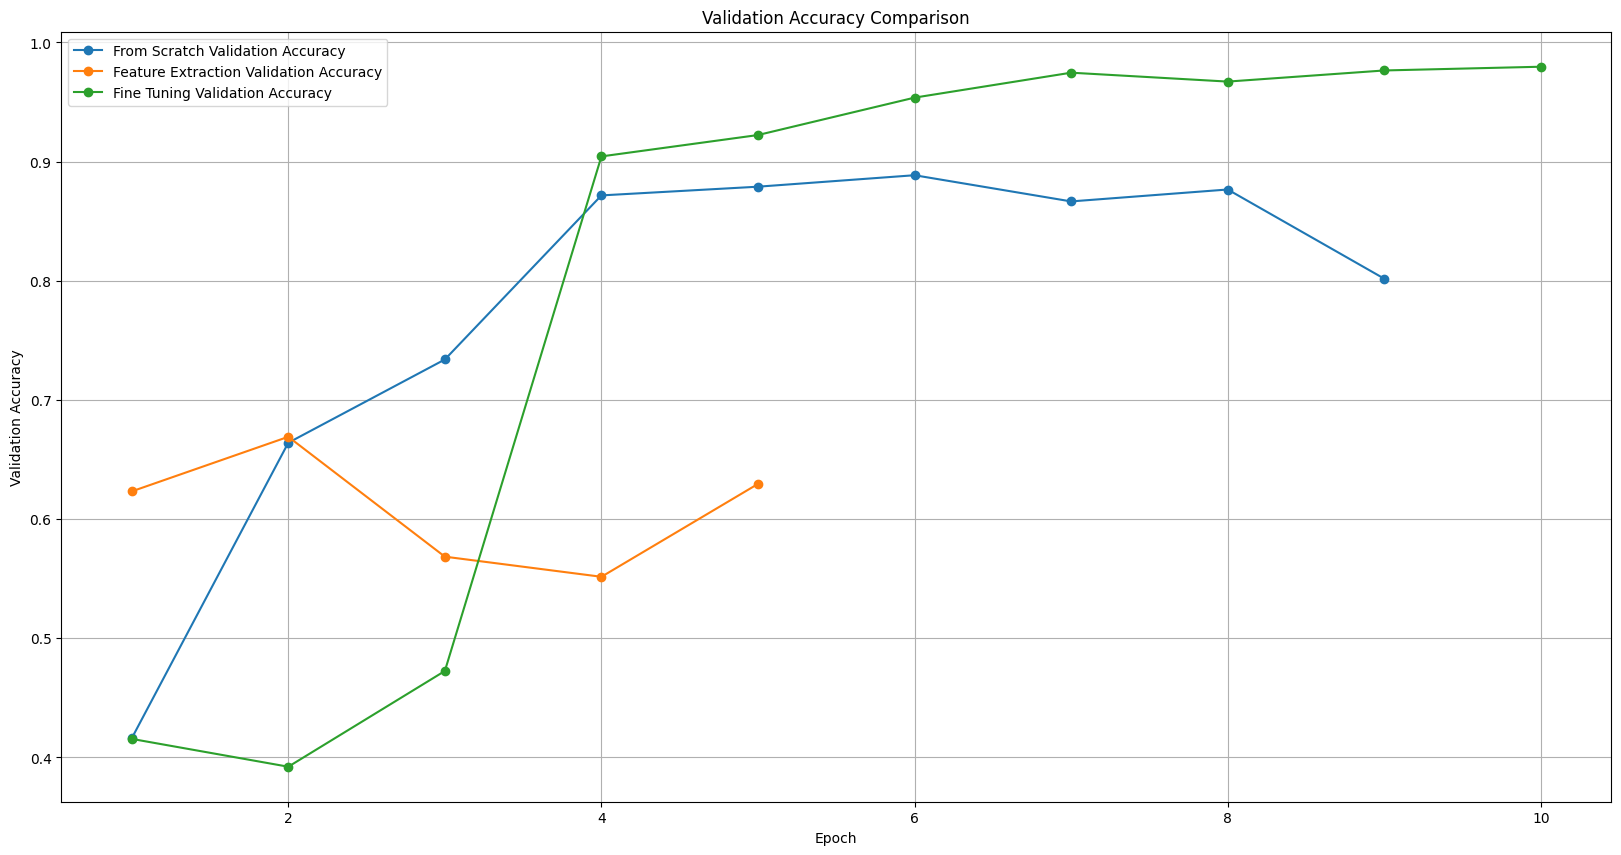

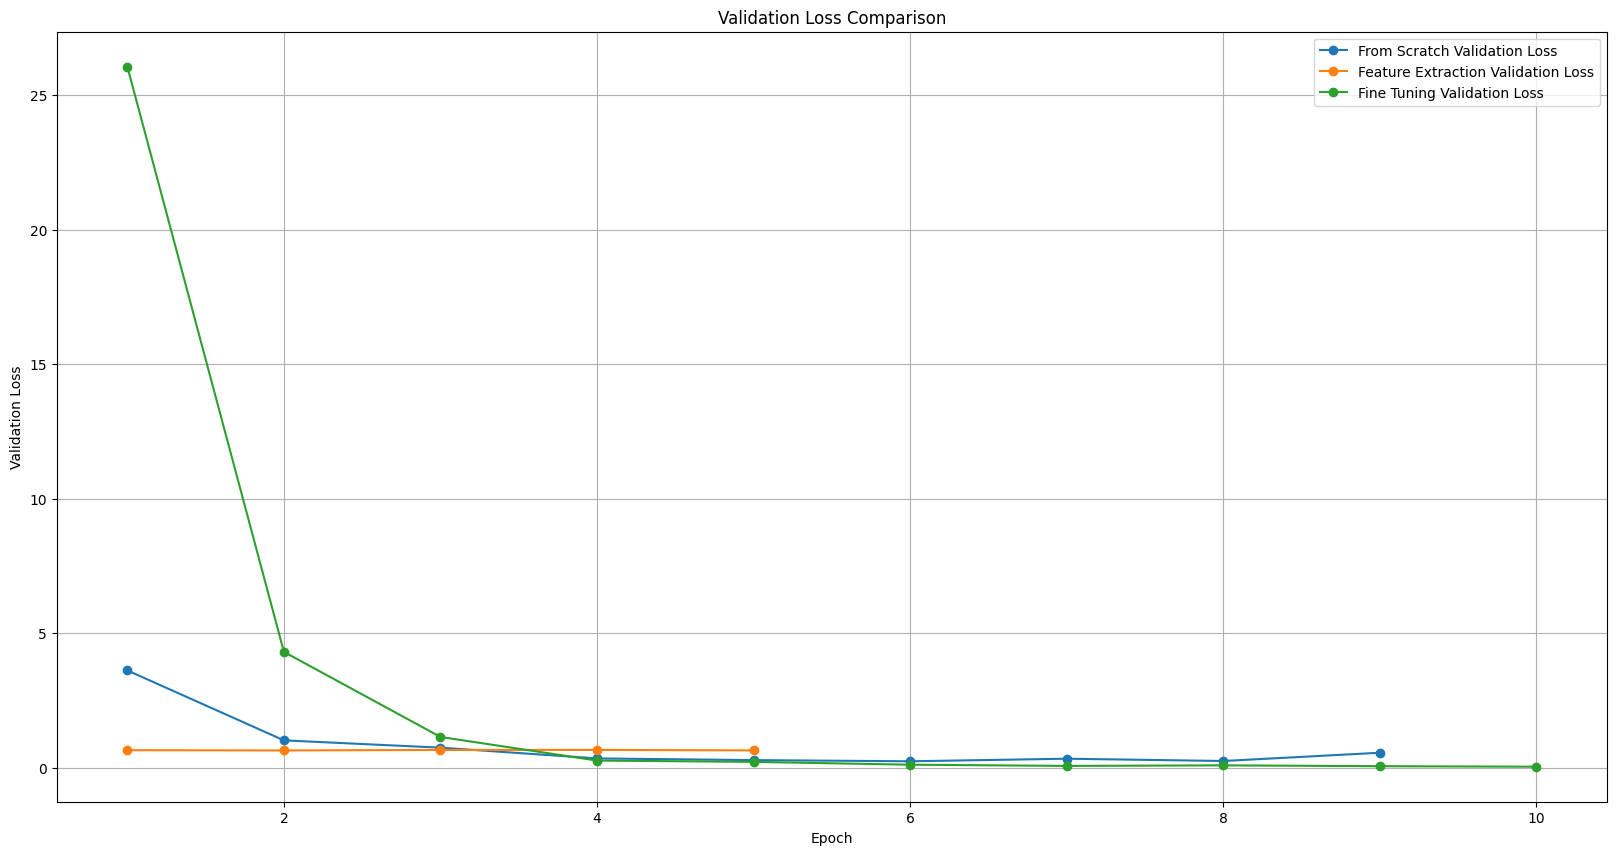

In [ ]:
def plot_history_no_subplots(histories, titles):
    # Validation Accuracy Comparison in a single large plot
    plt.figure(figsize=(20, 10))
    for i, history in enumerate(histories):
        epochs_range = range(1, len(history.history['val_accuracy']) + 1)
        plt.plot(epochs_range, history.history['val_accuracy'], marker='o',
                 label=f'{titles[i]} Validation Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Accuracy Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Validation Loss Comparison in a separate large plot
    plt.figure(figsize=(20, 10))
    for i, history in enumerate(histories):
        epochs_range = range(1, len(history.history['val_loss']) + 1)
        plt.plot(epochs_range, history.history['val_loss'], marker='o',
                 label=f'{titles[i]} Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history_no_subplots([history, history_feat, history_ft],
                         ["From Scratch", "Feature Extraction", "Fine Tuning"])

#### Training and Validation accuracy and loss

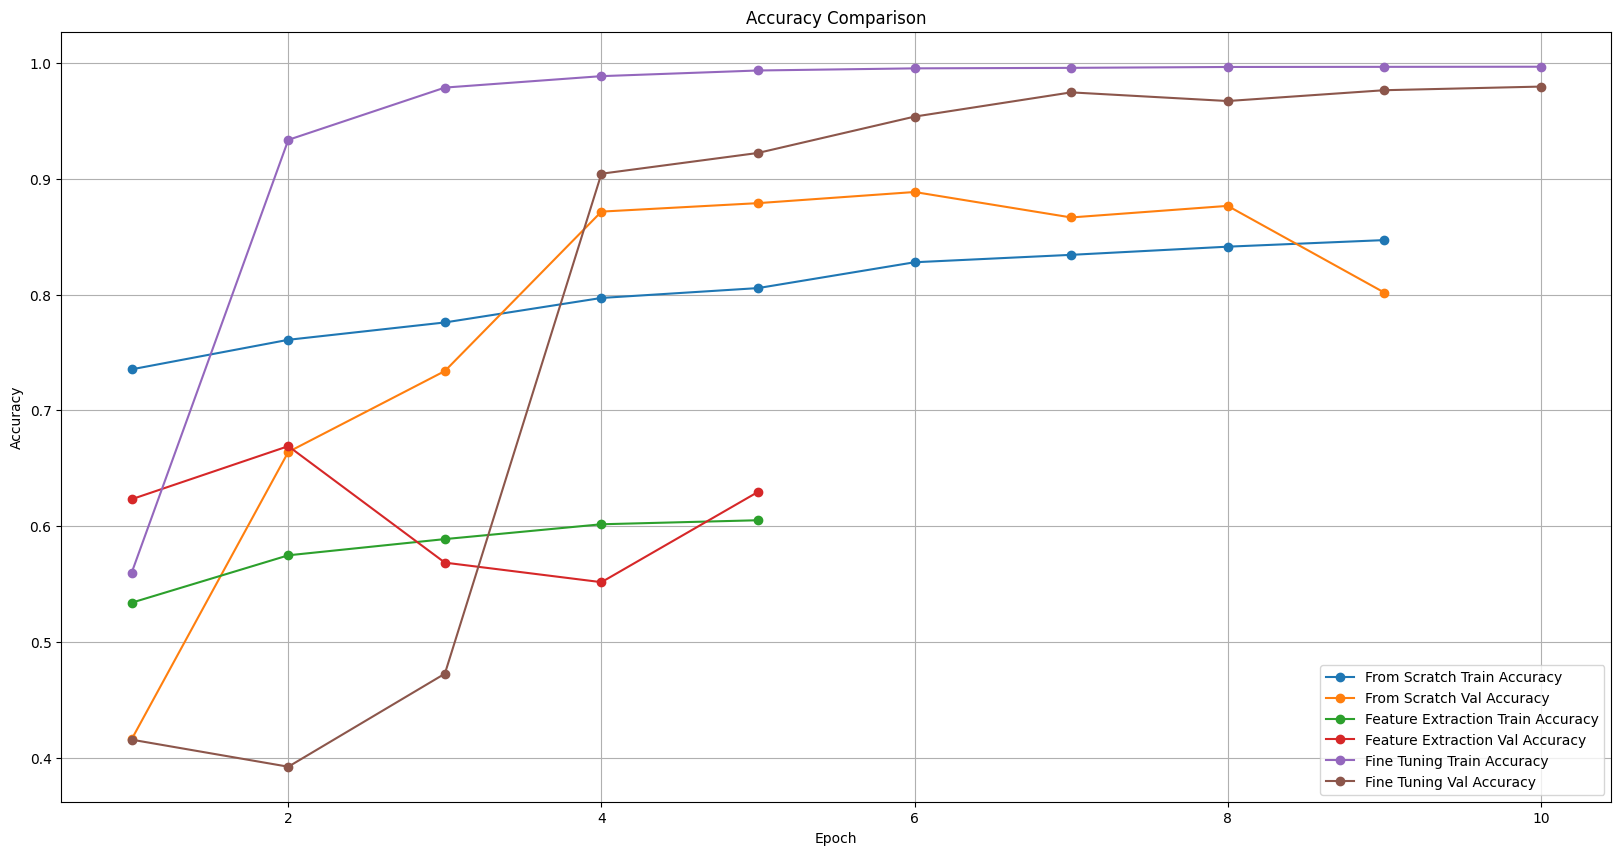

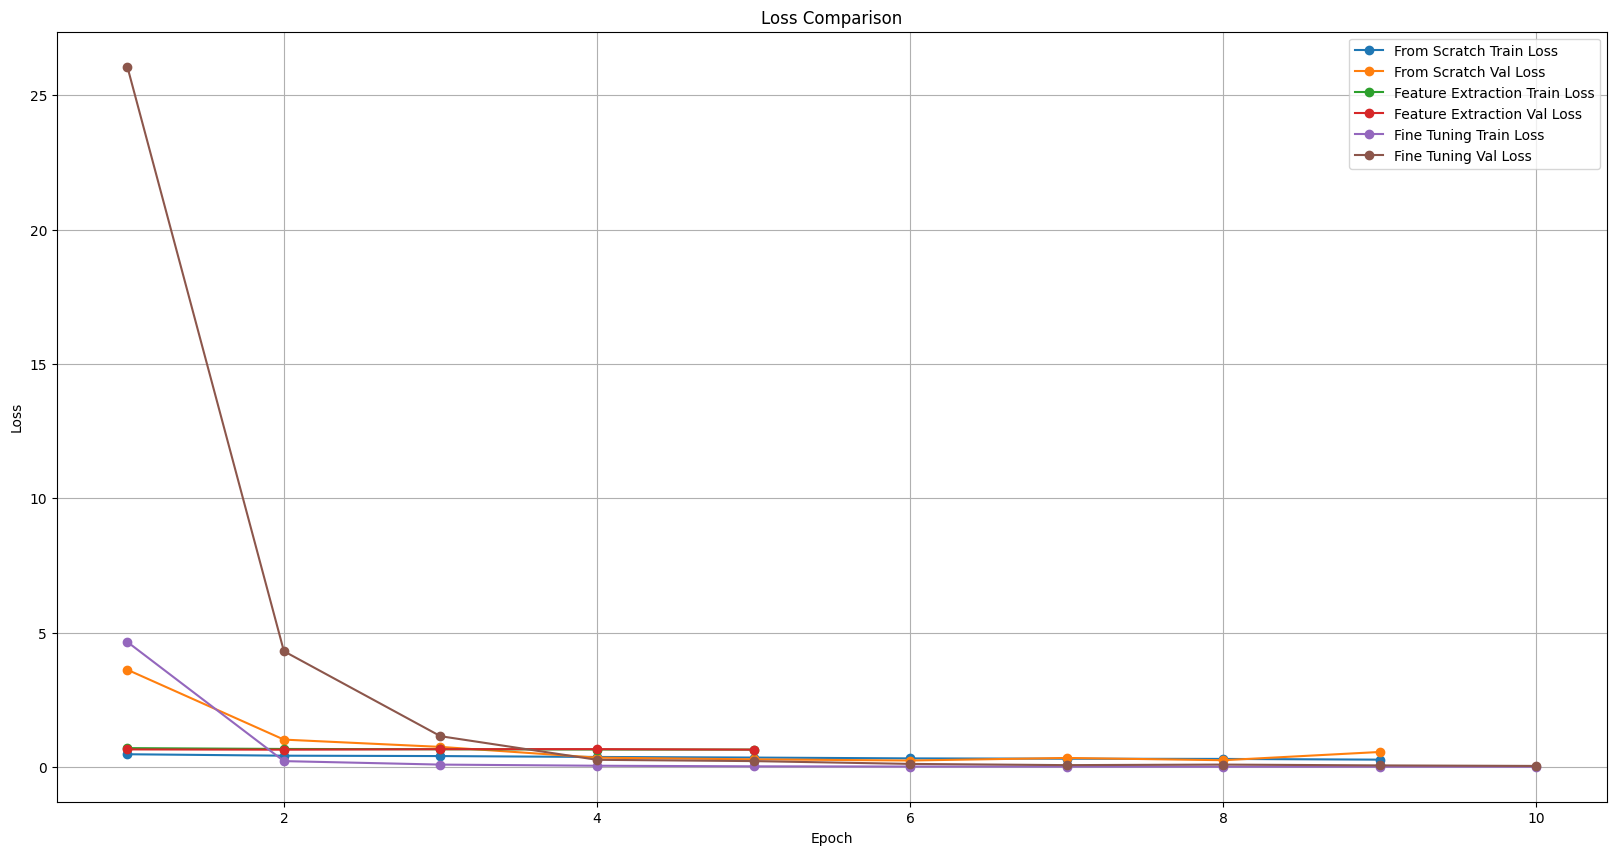

In [ ]:
def plot_history_no_subplots(histories, titles):
    # Accuracy Comparison in a single large plot
    plt.figure(figsize=(20, 10))
    for i, history in enumerate(histories):
        epochs_range = range(1, len(history.history['accuracy']) + 1)
        plt.plot(epochs_range, history.history['accuracy'], marker='o',
                 label=f'{titles[i]} Train Accuracy')
        plt.plot(epochs_range, history.history['val_accuracy'], marker='o',
                 label=f'{titles[i]} Val Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss Comparison in a separate large plot
    plt.figure(figsize=(20, 10))
    for i, history in enumerate(histories):
        epochs_range = range(1, len(history.history['loss']) + 1)
        plt.plot(epochs_range, history.history['loss'], marker='o',
                 label=f'{titles[i]} Train Loss')
        plt.plot(epochs_range, history.history['val_loss'], marker='o',
                 label=f'{titles[i]} Val Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history_no_subplots([history, history_feat, history_ft],
                         ["From Scratch", "Feature Extraction", "Fine Tuning"])

# Live testing

Evaluating model on test data...


Testing:   0%|          | 0/15 [00:00<?, ?it/s]

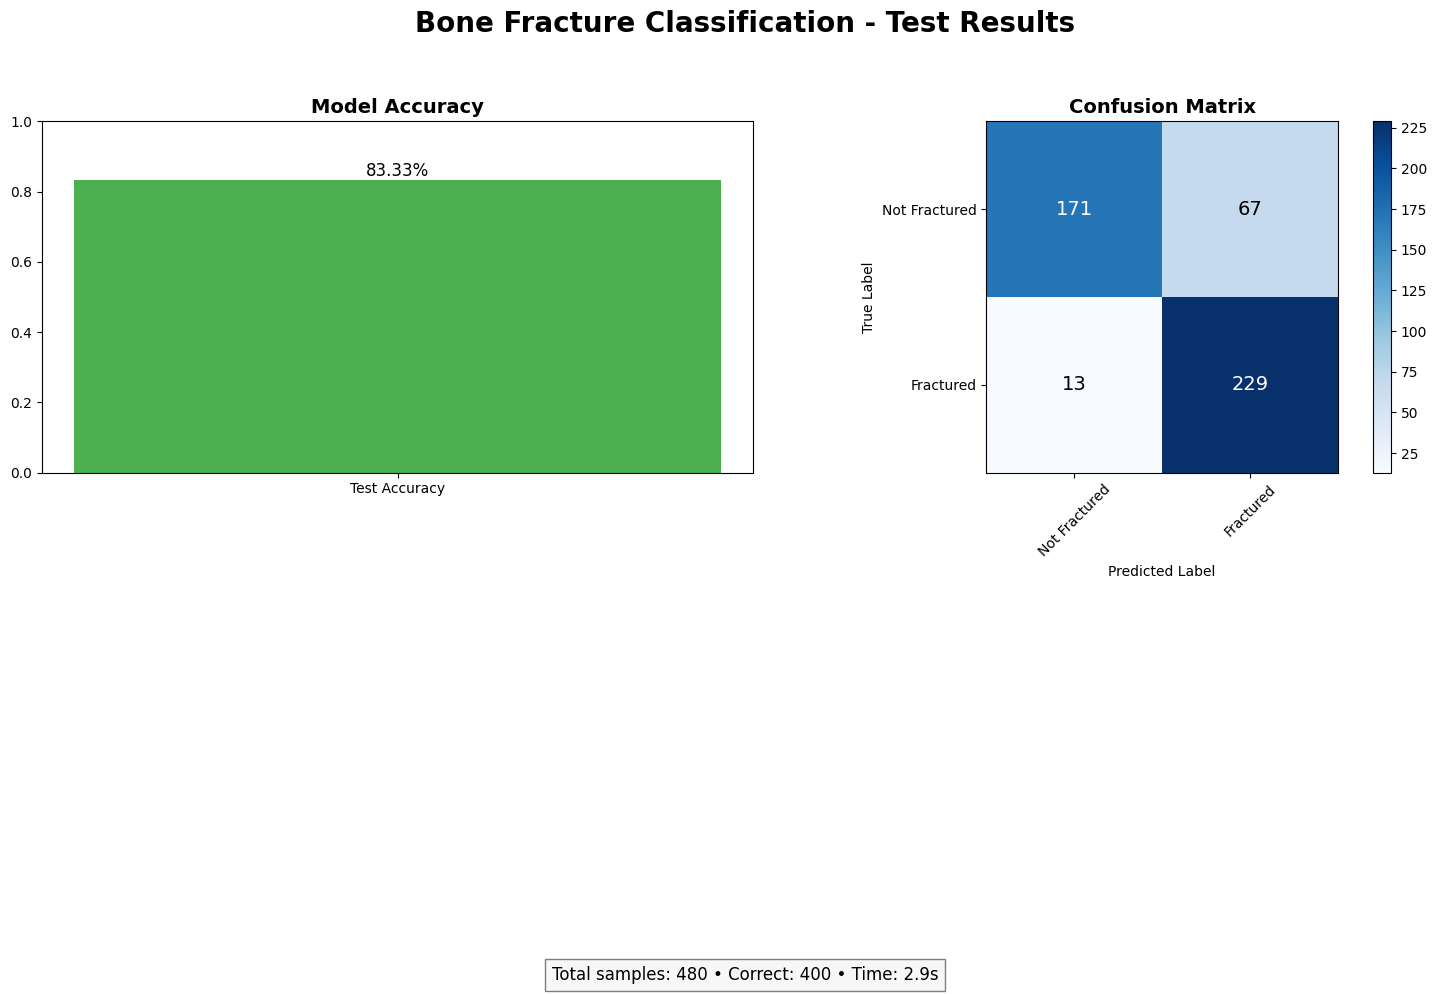

Final Test Accuracy: 0.8333 (83.33%)


In [59]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import time
from tqdm.notebook import tqdm

def elegant_evaluation(model, test_dataset, class_names):
    # Prepare for evaluation
    print("Evaluating model on test data...")
    total_samples = 0
    correct_predictions = 0
    all_predictions = []
    all_true_labels = []
    sample_images = []
    sample_preds = []
    sample_labels = []
    
    # First, count the number of batches for the progress bar
    batch_count = 0
    for _ in test_dataset:
        batch_count += 1
    
    # Process each batch with a progress bar instead of flashing updates
    start_time = time.time()
    for images, labels in tqdm(test_dataset, total=batch_count, desc="Testing"):
        # Get predictions
        predictions = model.predict(images, verbose=0)
        pred_classes = tf.cast(predictions > 0.5, tf.int32)
        
        # Update metrics
        batch_size = len(images)
        total_samples += batch_size
        batch_correct = tf.reduce_sum(tf.cast(tf.equal(pred_classes, tf.cast(labels, tf.int32)), tf.int32))
        correct_predictions += batch_correct
        
        # Store for confusion matrix
        all_predictions.extend(pred_classes.numpy().flatten())
        all_true_labels.extend(labels.numpy().flatten())
        
        # Save a few samples for visualization
        if len(sample_images) < 6:  # Only keep a few samples
            for i in range(min(2, batch_size)):  # Take up to 2 samples from each batch
                sample_images.append(images[i].numpy())
                sample_preds.append(pred_classes[i].numpy()[0])
                sample_labels.append(labels[i].numpy()[0])
    
    # Calculate final accuracy
    final_acc = correct_predictions / total_samples
    
    # Now create a beautiful final visualization
    plt.figure(figsize=(15, 10))
    plt.subplots_adjust(hspace=0.4, wspace=0.4)
    
    # Main header
    plt.suptitle("Bone Fracture Classification - Test Results", 
                 fontsize=20, fontweight='bold', y=0.98)
    
    # 1. Accuracy display
    plt.subplot(2, 2, 1)
    plt.bar(['Test Accuracy'], [final_acc.numpy()], color='#4CAF50')
    plt.ylim(0, 1)
    for bar in plt.gca().patches:
        plt.gca().text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.01,
                 f"{bar.get_height():.2%}", 
                 ha='center', fontsize=12)
    plt.title("Model Accuracy", fontsize=14, fontweight='bold')
    
    # 2. Confusion Matrix with prettier styling
    plt.subplot(2, 2, 2)
    cm = tf.math.confusion_matrix(all_true_labels, all_predictions).numpy()
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    
    # Add pretty text annotations to confusion matrix
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    
    
    # Add a summary at the bottom
    plt.figtext(0.5, 0.01, 
               f"Total samples: {total_samples} • Correct: {correct_predictions.numpy()} • Time: {time.time() - start_time:.1f}s",
               ha="center", fontsize=12, bbox={"facecolor":"#f0f0f0", "alpha":0.5, "pad":5})
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    return final_acc.numpy()

# Usage:
test_ds_clean = test_ds.apply(tf.data.experimental.ignore_errors())
class_names = ["Not Fractured", "Fractured"]  # Adjust if different

# Run evaluation with elegant visualization
final_accuracy = elegant_evaluation(model_scratch, test_ds_clean, class_names)
print(f"Final Test Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")